# Main file calling for different methods
> REMEMBER TO TUNE THE PARAMETERS FOR THE METHODS!
* `randomize` describes how many different combinations of the parameter grid in each method is to be used. The higher the slower. 0 means check all.
* `verbosity` describes how much info one wants from the method. 0 is none, 3 and above is a lot
* `test_size` is the proportion or size of the test set when splitting the data in the algorithm.
* `n_splits` is the number of splits made in the stratified k fold/cross validation.
* `repeated_CV` boolean describing if it is to use repeated stratified k fold. Robust but slow.
> Some methods use `bagging` or `bayes` as parameters, too.
* `bagging` boolean describing if bagging is to be used or not. Slow, does not seem to increase accuracy where it is used for the moment.
* `bayes` boolean describing if bayesian optimisation of the parameters is to be used. Searching over continuous intervals. Extremely slow, many hours.

## Import packages and preparing data

In [1]:
import pandas as pd
import importlib    # To avoid having to restart the kernel every time changes are made
import treebased_methods as tbm
import svm_methods as svm
import NN_methods as NNm
import data_cleaning as dc
import plot_learning_results as plt_lr
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, train_test_split # Using in each method instead
import numpy as np
import csv


In [2]:
train = pd.read_csv(
    r"Data/project_train.csv",
    sep=",",
    decimal=".",    )

train.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,Label
0,0.545,0.884,5,-4.807,0,0.367,0.290000,0.000000,0.370,0.641,86.049,1
1,0.795,0.545,7,-8.153,1,0.343,0.003960,0.000000,0.273,0.809,91.967,1
2,0.489,0.871,5,-5.825,1,0.386,0.002850,0.000004,0.130,0.341,117.431,1
3,0.539,0.931,4,-1.803,0,0.262,0.000713,0.000000,0.204,0.685,85.571,0
4,0.918,0.734,11,-2.832,0,0.269,0.029400,0.000008,0.191,0.608,97.044,1


### Small set and balanced label with no missing data. Nice!

In [556]:
missing_values = train.isnull().sum()
df_info = pd.DataFrame({
                        "Missing values": missing_values,
                        "Data type": train.dtypes
                        })
print(train.shape[0])
print(train.nunique())
print(train.groupby(["Label"]).size())
df_info

505
danceability        358
energy              381
key                  12
loudness            487
mode                  2
speechiness         357
acousticness        411
instrumentalness    303
liveness            339
valence             405
tempo               492
Label                 2
dtype: int64
Label
0    252
1    253
dtype: int64


,Missing values,Data type
danceability,0,float64
energy,0,float64
key,0,int64
loudness,0,float64
mode,0,int64
speechiness,0,float64
acousticness,0,float64
instrumentalness,0,float64
liveness,0,float64
valence,0,float64


### Separate set into features and labels

In [3]:
X_df = train.iloc[:, :-1]  # All columns except the label
y_df = train.iloc[:, -1]   # The y or label column

# Check distribution of features
> The data is clearly not normally distributed. Excluding the use of LDA and QDA. Also, the data features are clearly not mutually independent, excluding the use of naive bayes. There are also a lot of outliers as seen in boxplot, and especially one as seen in parplot. To get around this problem, we cannot simply remove them since it affects the small data set a lot. Therefore, we use ridge regressors in `sklearn`'s iterative imputer.

In [558]:
# Run this if changes to the data_cleaning file has been made
importlib.reload(dc)

<module 'data_cleaning' from 'c:\\Users\\ville\\MinaPythonProgram\\SF2935StatLearning\\data_cleaning.py'>

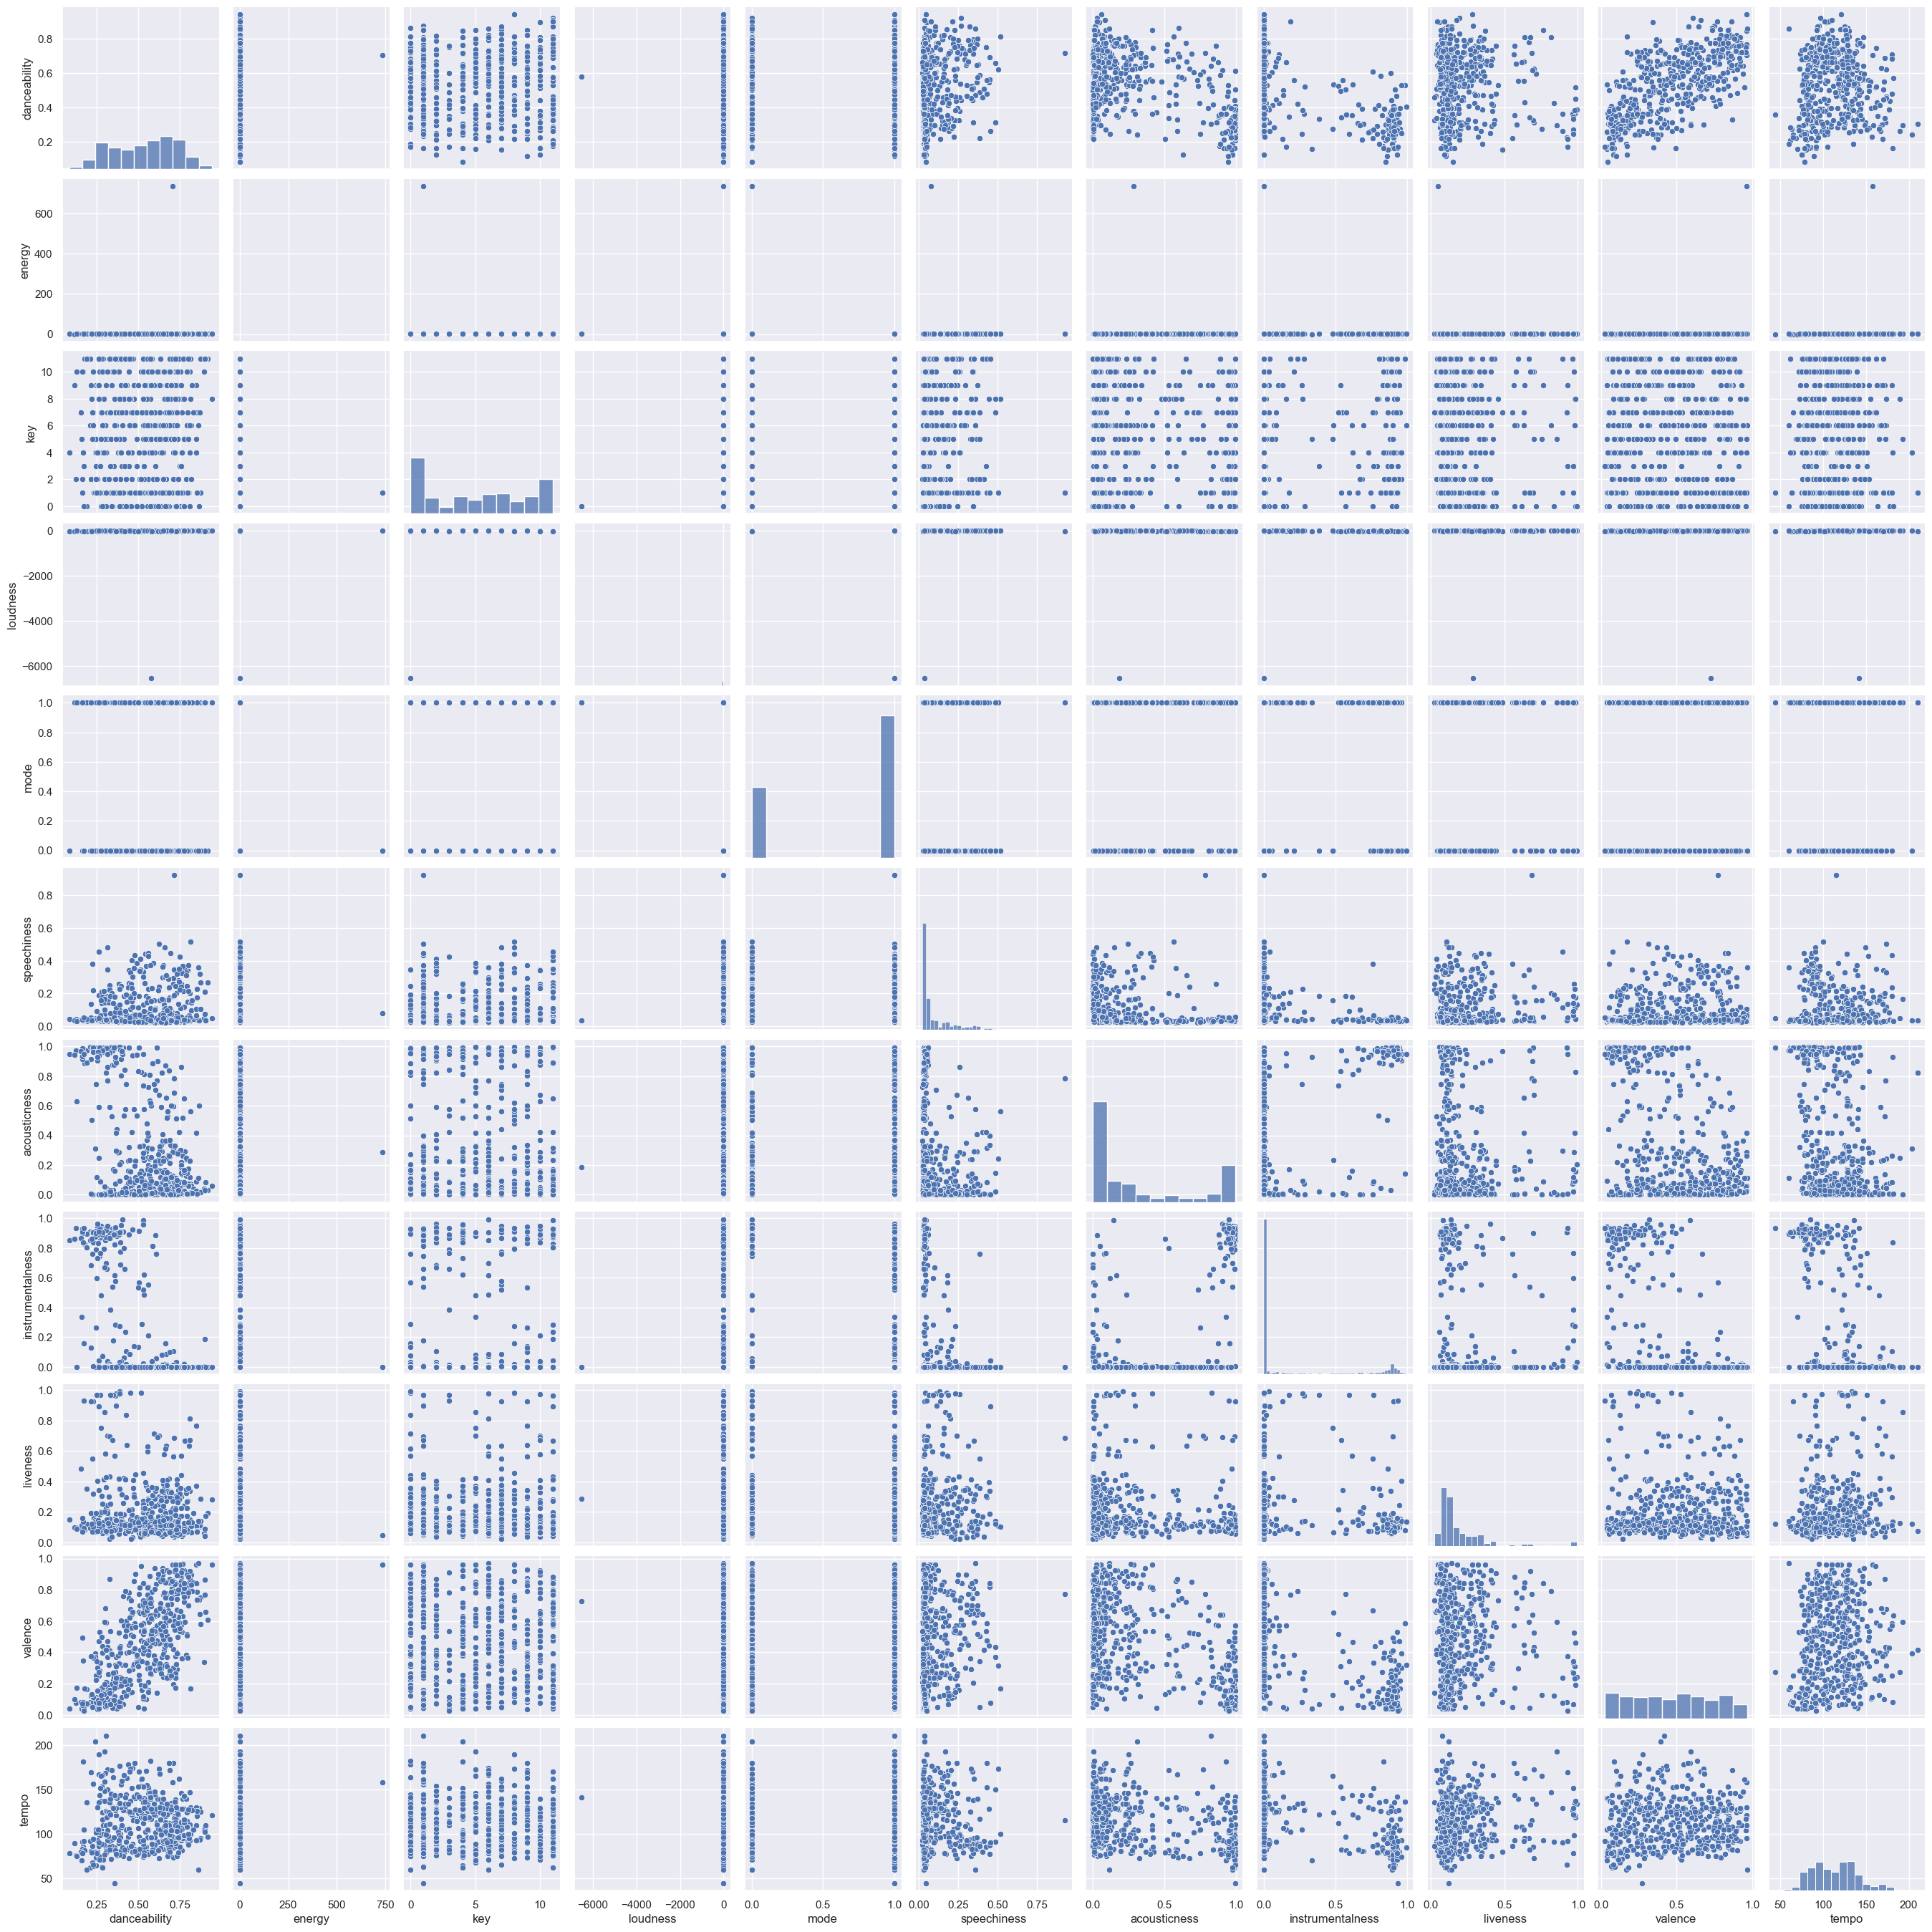

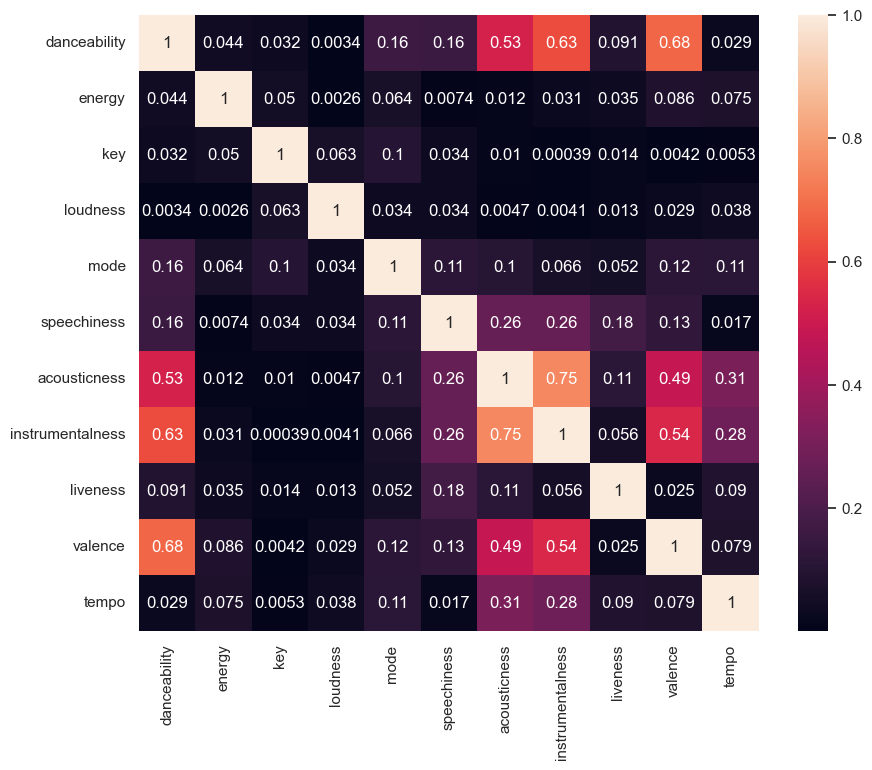

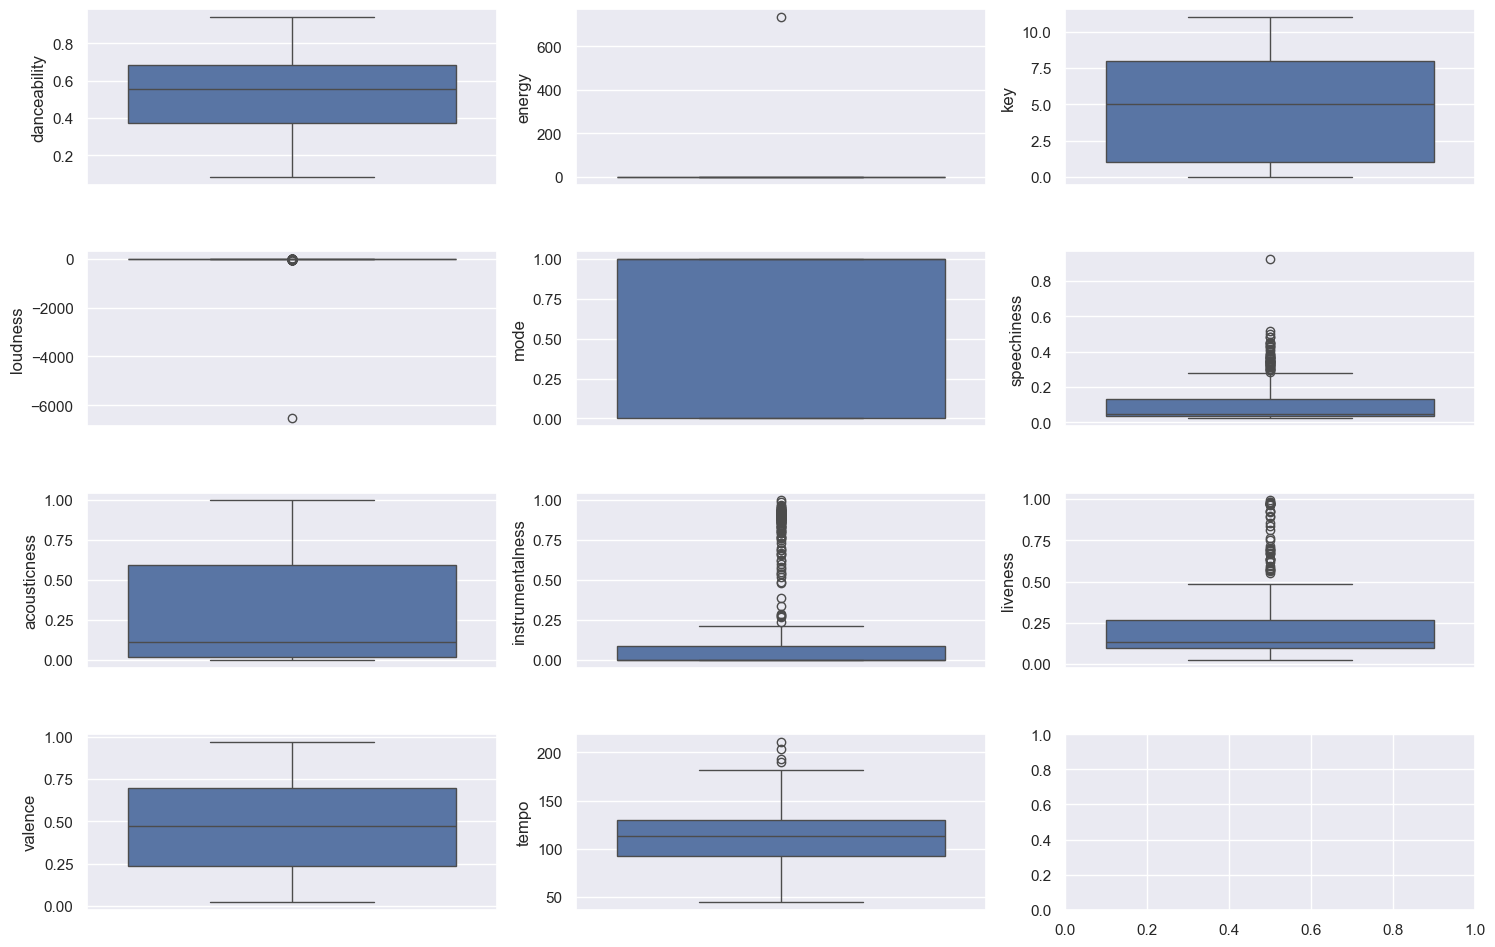

In [559]:
dc.plot_dist(X_df)

### Clean data
> Need to remove outliers for the outlier sensitive learning algorithms such as NN, SVM, NB, KNN.
We also have high correlation between features! This indicates either feature selection or transformation to remove the linear correlation. Therefore, we add either LAsso, PCA or Ridge to our models instead of choosing features manually. However, it can be good to do it manually to actually see if we can get rid of it and if it is then some non-linear relations disturbing the learning of our methods making it preferable to keep the severe outlier which makes the features less correlated.

In [560]:
X_clean_df = dc.clean_data(X_df, low_quant=0.005, up_quant=0.995, replace=True)

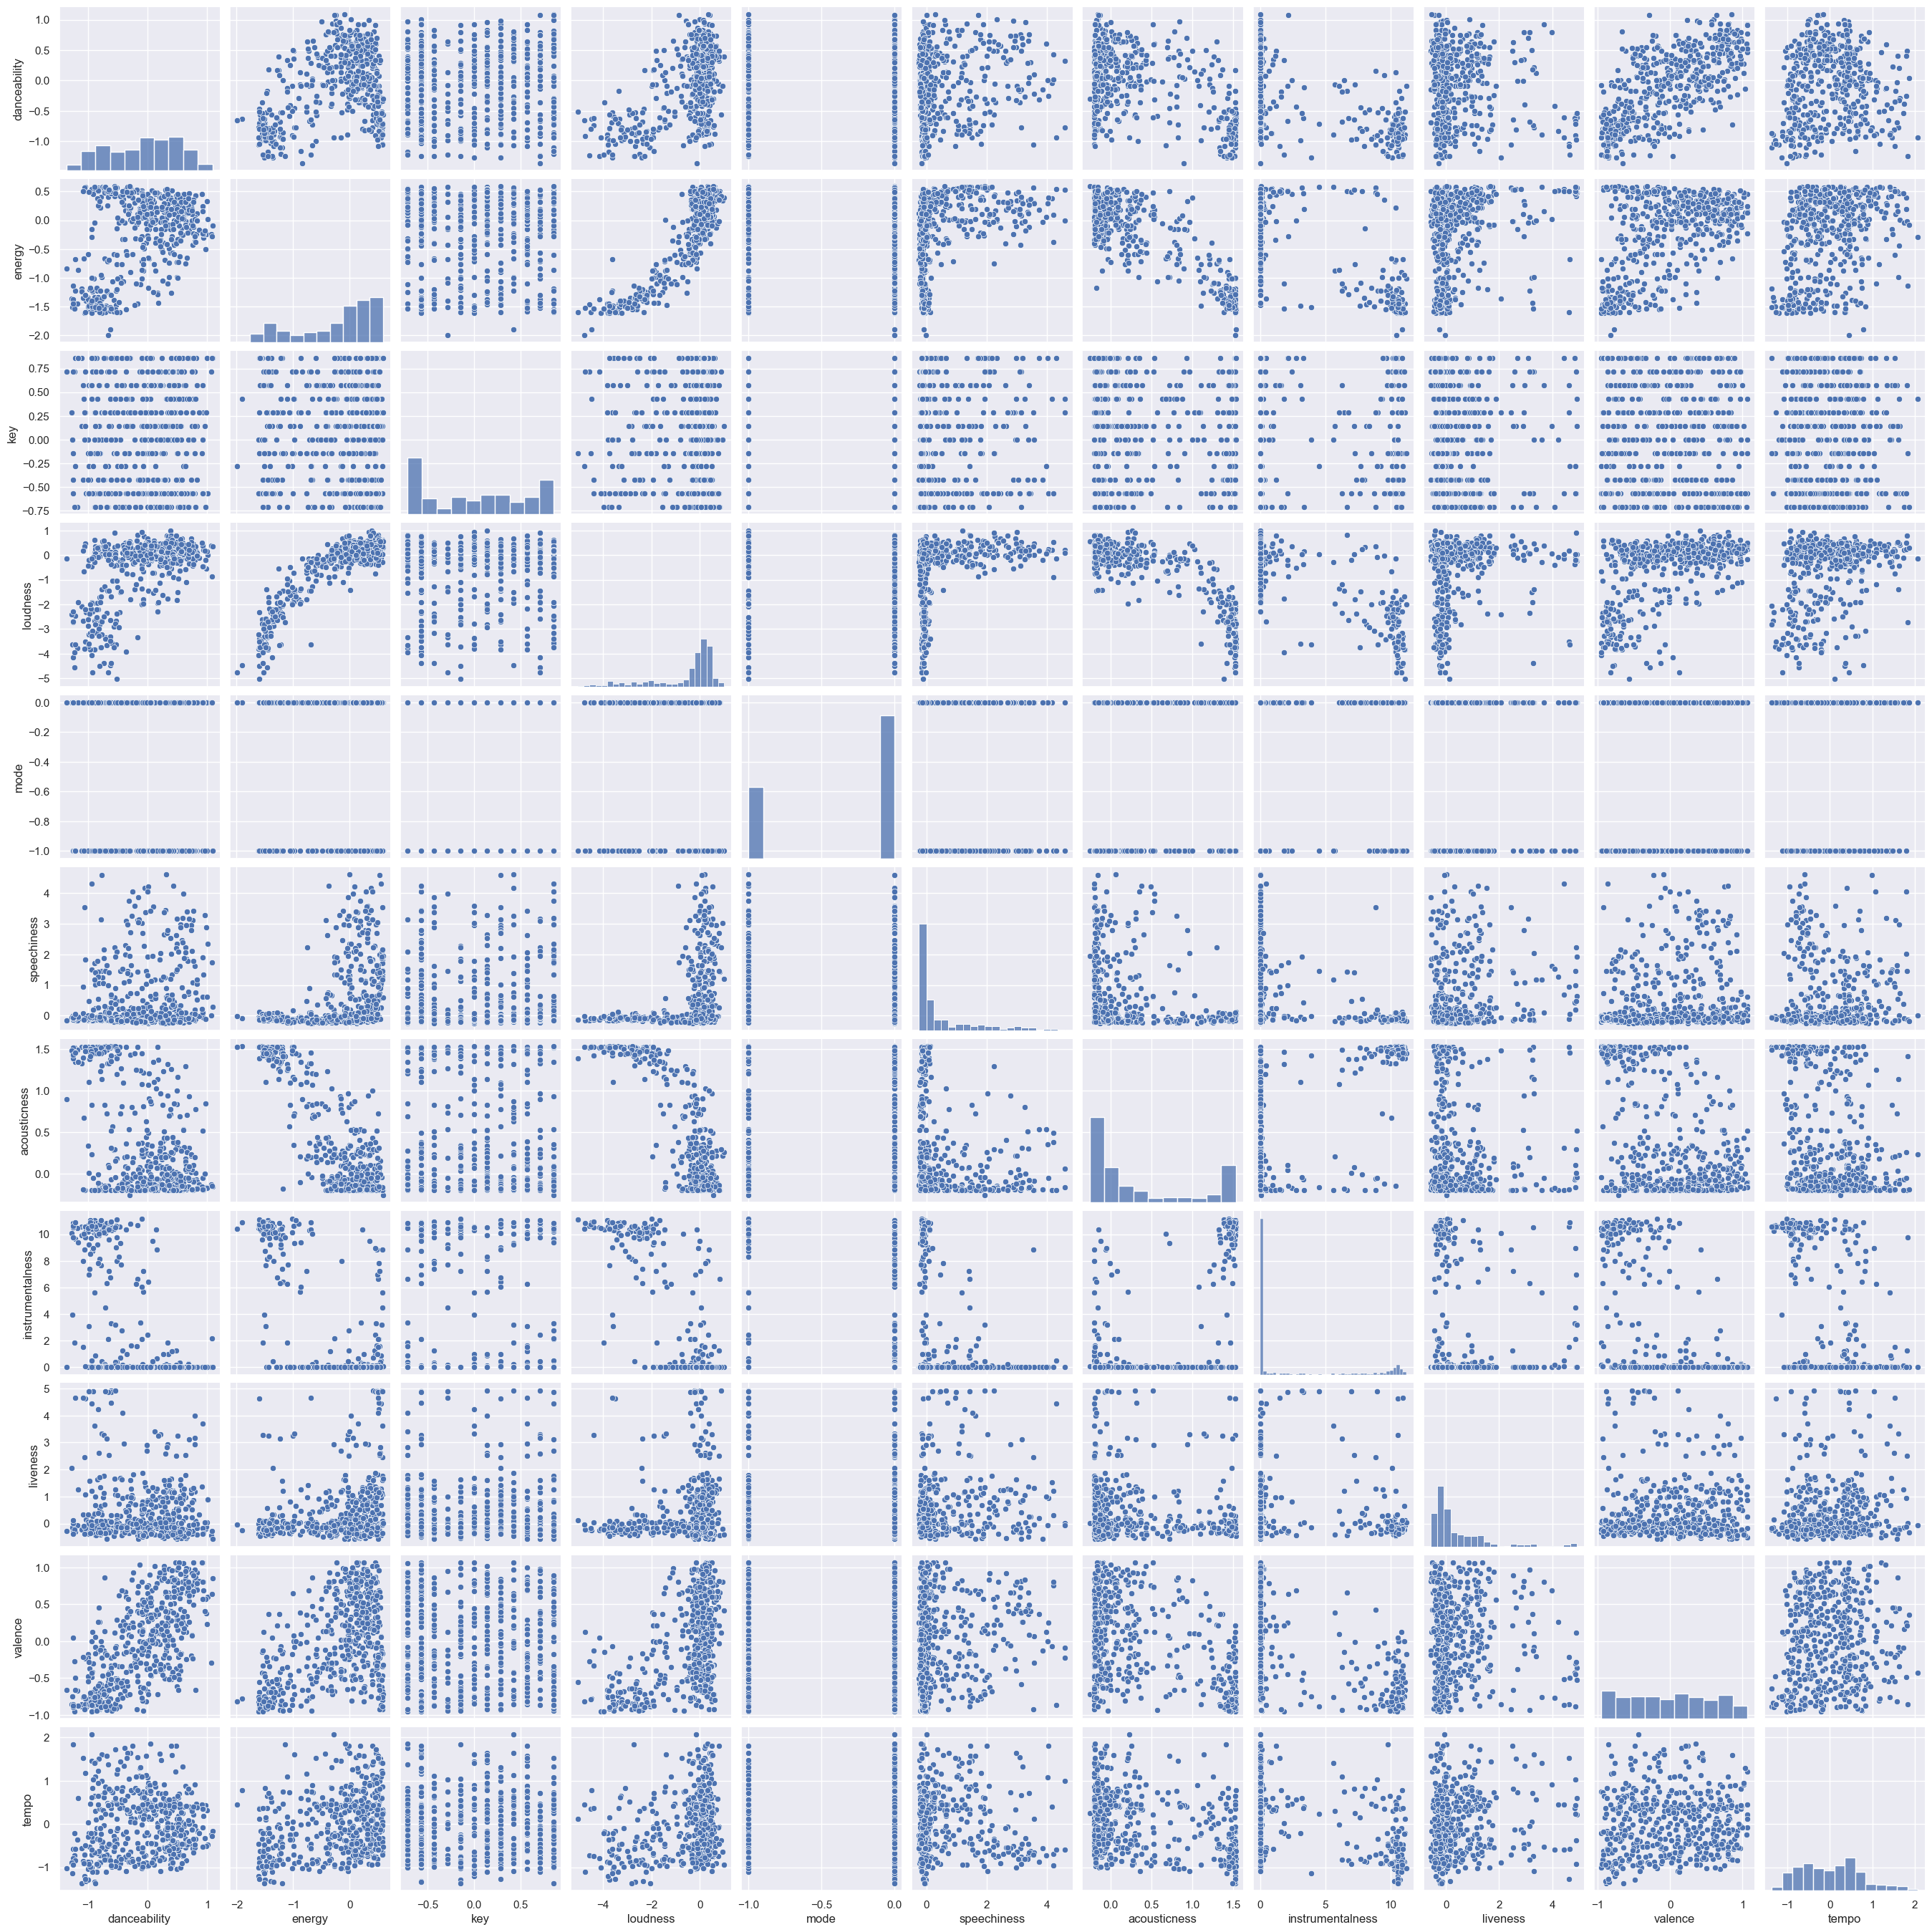

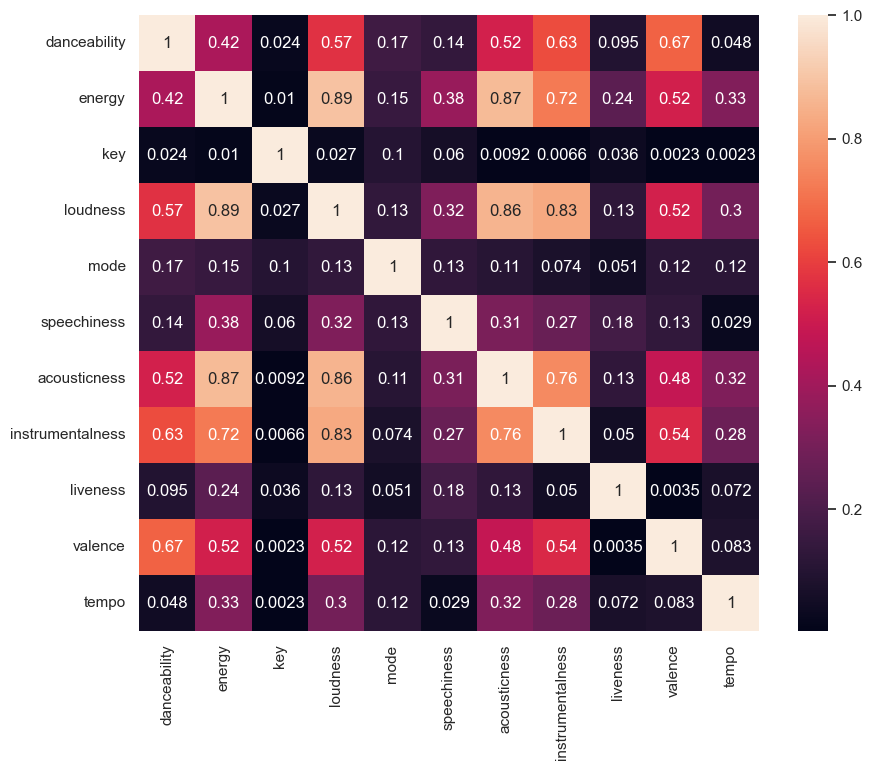

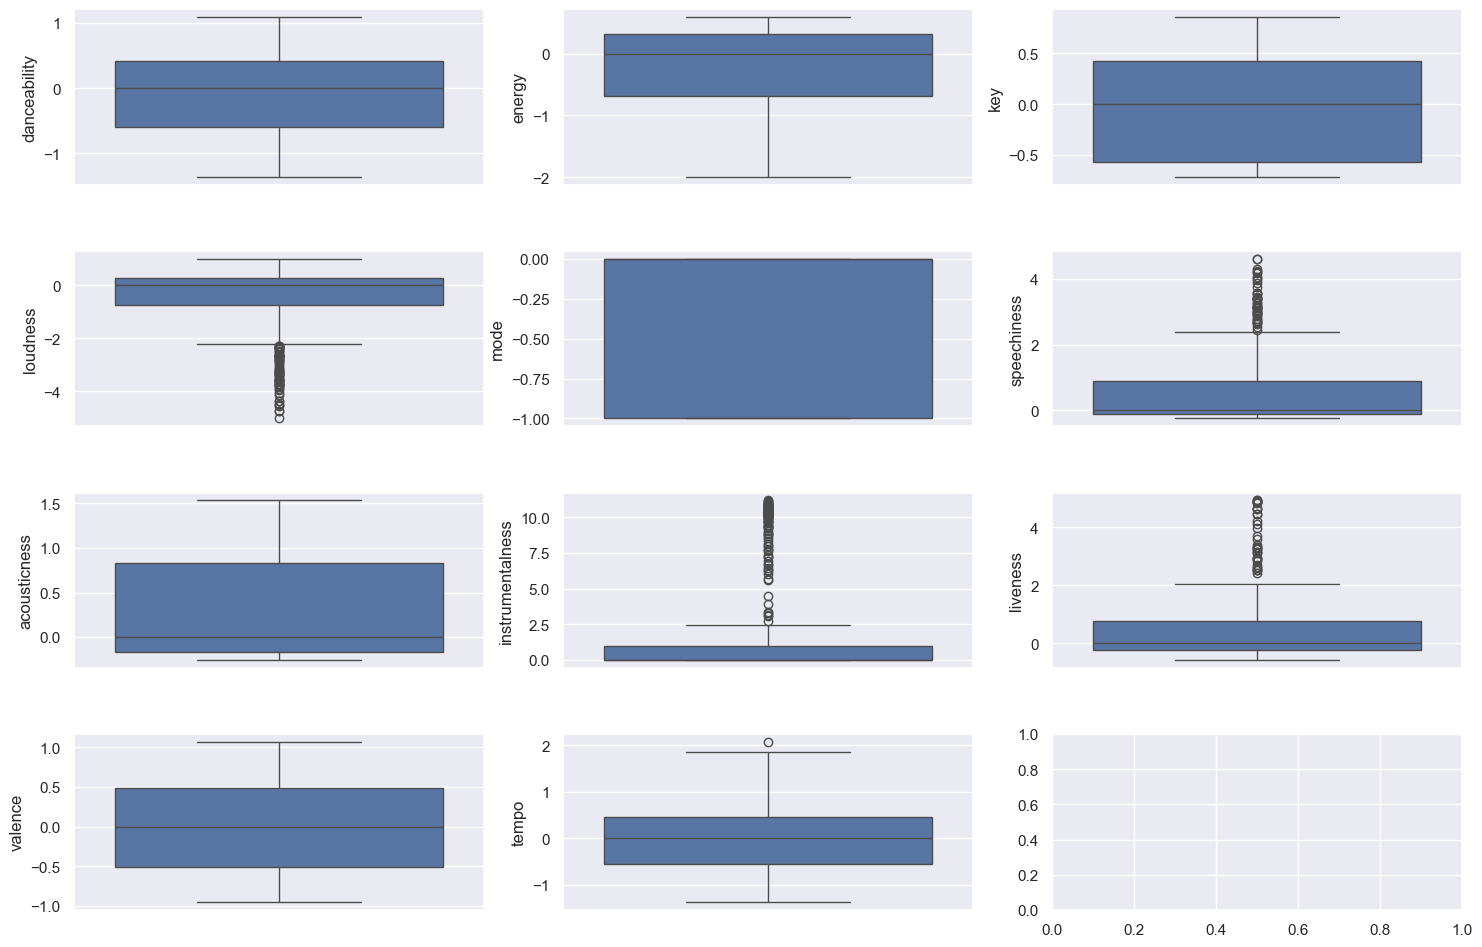

In [561]:
dc.plot_dist(X_clean_df)

# Run this code and plot again, if you feel for it. Just testing to drop som high correlated features.

In [562]:
X_clean_df_ny = X_clean_df.drop(columns=["energy", "acousticness"])

As we can see, after imputing outliers the features became much higher linear correlated... We can get around this issue by using the methods mentioned above.

In [4]:
X = X_df.values     # Creating numpy instances of the data frames
y = y_df.values
# X_clean = X_clean_df_ny.values

In [564]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [565]:
vif_data = pd.DataFrame()
vif_data["feature"] = X_clean_df_ny.columns

vif_data["VIF"] = [variance_inflation_factor(X_clean_df_ny.values, i) for i in range(len(X_clean_df_ny.columns))]

print(vif_data)

            feature       VIF
0      danceability  2.377759
1               key  1.014429
2          loudness  4.120592
3              mode  1.336659
4       speechiness  1.261319
5  instrumentalness  4.553376
6          liveness  1.206803
7           valence  1.890537
8             tempo  1.106650


## Running tree based methods
These are not sensitive for outliers (or categorical data), so no cleaned data set needed.

In [5]:
# Run this cell if changes to tree based methods have been made
importlib.reload(tbm)

<module 'treebased_methods' from 'c:\\Users\\ville\\MinaPythonProgram\\SF2935StatLearning\\treebased_methods.py'>

In [567]:
lgb_model, lgb_results = tbm.lgb_method(X, y, n_splits=3, repeatedCV=True, bayes=False, randomize=250)

Fitting 9 folds for each of 250 candidates, totalling 2250 fits
LightGBM accuracy on training data: 0.8316749585406301
Best LightGBM parameters: {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.01, 'lambda_l2': 0.5, 'lambda_l1': 0}
LightGBM accuracy on test data: 0.8415841584158416


In [7]:
xgb_model, xgb_results = tbm.xgb_method(X, y, n_splits=3, repeatedCV=False, randomize=0, test_size=0.2, verbosity=5)

Fitting 3 folds for each of 101250 candidates, totalling 303750 fits
XGB accuracy on training data: 0.8538971807628525
Best XGB parameters: {'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 50, 'reg_alpha': 0.1, 'reg_lambda': 0.5, 'subsample': 0.6}
XGB accuracy on test data: 0.8217821782178217


## Running Support Vector Machines

In [569]:
# Run this cell if changes to svm methods have been made
importlib.reload(svm)

<module 'svm_methods' from 'c:\\Users\\ville\\MinaPythonProgram\\SF2935StatLearning\\svm_methods.py'>

In [8]:
svm_model, svm_results = svm.svm_method(X, y, n_splits=3, randomize=250, test_size=0.2, verbosity=3)

Fitting 3 folds for each of 250 candidates, totalling 750 fits
SVM accuracy on training data: 0.8241938455868804
Best SVM parameters: {'svm__kernel': 'rbf', 'svm__gamma': 0.1, 'svm__C': 1, 'select__k': 10, 'pca__n_components': 0.99}
SVM accuracy on test data: 0.7920792079207921


## Running Neural Network

In [502]:
# Run this cell if changes to neural network methods have been made
importlib.reload(NNm)

<module 'NN_methods' from 'c:\\Users\\ville\\MinaPythonProgram\\SF2935StatLearning\\NN_methods.py'>

In [14]:
NN_model, NN_results = NNm.NN_method(X, y, n_splits=3, repeatedCV=False, randomize=250, test_size=0.3)

Fitting 3 folds for each of 250 candidates, totalling 750 fits
Neural network accuracy on training data: 0.8384518808247622
Best neural network parameters: {'model__weight_decay': 0.0001, 'model__patience': 100, 'model__optimizer_class': <class 'torch.optim.adam.Adam'>, 'model__num_epochs': 25, 'model__loss_func_class': <class 'torch.nn.modules.loss.BCELoss'>, 'model__learning_rate': 0.001, 'model__hidden_layer_sizes': (150, 50), 'model__activation': <class 'torch.nn.modules.activation.ReLU'>}
Neural network accuracy on test data: 0.7631578947368421


In [506]:
NN_model_clean, NN_results_clean = NNm.NN_method(X_clean, y, n_splits=3, repeatedCV=True, randomize=250)

Fitting 9 folds for each of 250 candidates, totalling 2250 fits
Neural network accuracy on training data: 0.83092697216991
Best neural network parameters: {'model__weight_decay': 0.0001, 'model__patience': 100, 'model__optimizer_class': <class 'torch.optim.adam.Adam'>, 'model__num_epochs': 50, 'model__loss_func_class': <class 'torch.nn.modules.loss.BCELoss'>, 'model__learning_rate': 0.001, 'model__hidden_layer_sizes': (150, 50), 'model__activation': <class 'torch.nn.modules.activation.ReLU'>}
Neural network accuracy on test data: 0.7631578947368421


## Plotting learning curves

In [571]:
importlib.reload(plt_lr)

<module 'plot_learning_results' from 'c:\\Users\\ville\\MinaPythonProgram\\SF2935StatLearning\\plot_learning_results.py'>

Using the k features chosen in svm

In [10]:
X_svm = svm_model.named_steps['select'].transform(X)


In [15]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
rskf = RepeatedStratifiedKFold(n_splits=3, n_repeats=3, random_state=42)
models = {
    'SVM': (svm_model, skf, X_svm),
    # 'KNN': (knn_model, rskf),
    # 'LGB': (lgb_model, rskf, X),
    'XGB': (xgb_model, rskf, X),
    'NN': (NN_model, rskf, X),
    # 'NN_X_clean': (NN_model_clean, rskf, X_clean),
    # 'NN_scipy': (NN_model_sci, rskf),
}

cv_results = {
    'SVM': svm_results,
    # 'KNN': knn_results,
    # 'LGB': lgb_results,
    'XGB': xgb_results,
    'NN': NN_results,
    # 'NN_X_clean': NN_results_clean,
    # 'NN_scipy': NN_sci_results
}

SVM plot computed
XGB plot computed
NN plot computed


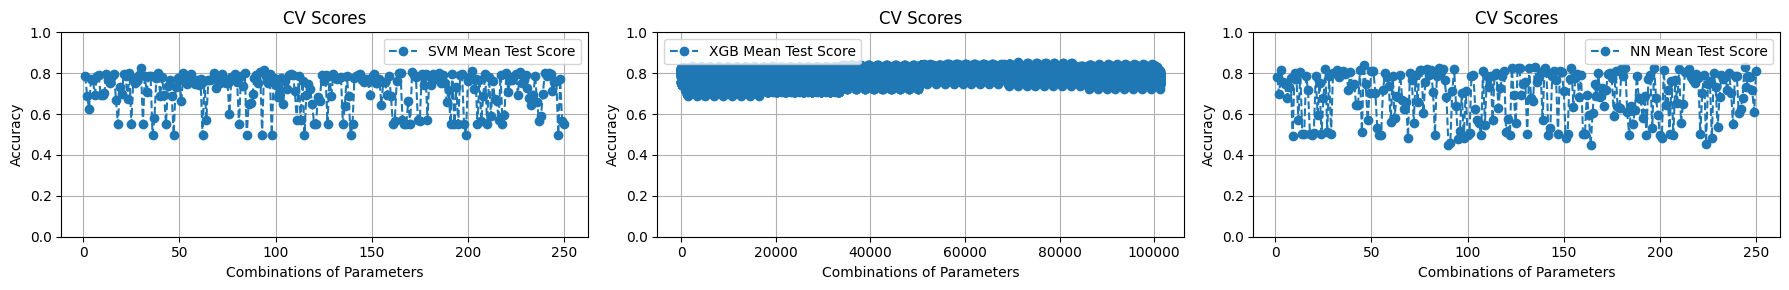

In [16]:
plt_lr.plot_cv_results(cv_results=cv_results)

[learning_curve] Training set sizes: [ 33  67 100 134 168 201 235 268 302 336]
SVM plot computed
[learning_curve] Training set sizes: [ 33  67 100 134 168 201 235 268 302 336]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 out of  30 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  20 out of  30 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  29 out of  90 | elapsed:    0.2s remaining:    0.6s
[Parallel(n_jobs=-1)]: Done  60 out of  90 | elapsed:    0.5s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done  90 out of  90 | elapsed:    0.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


XGB plot computed
[learning_curve] Training set sizes: [ 33  67 100 134 168 201 235 268 302 336]


[Parallel(n_jobs=-1)]: Done  29 out of  90 | elapsed:    1.3s remaining:    2.8s
[Parallel(n_jobs=-1)]: Done  60 out of  90 | elapsed:    2.5s remaining:    1.2s
[Parallel(n_jobs=-1)]: Done  90 out of  90 | elapsed:    3.7s finished


NN plot computed


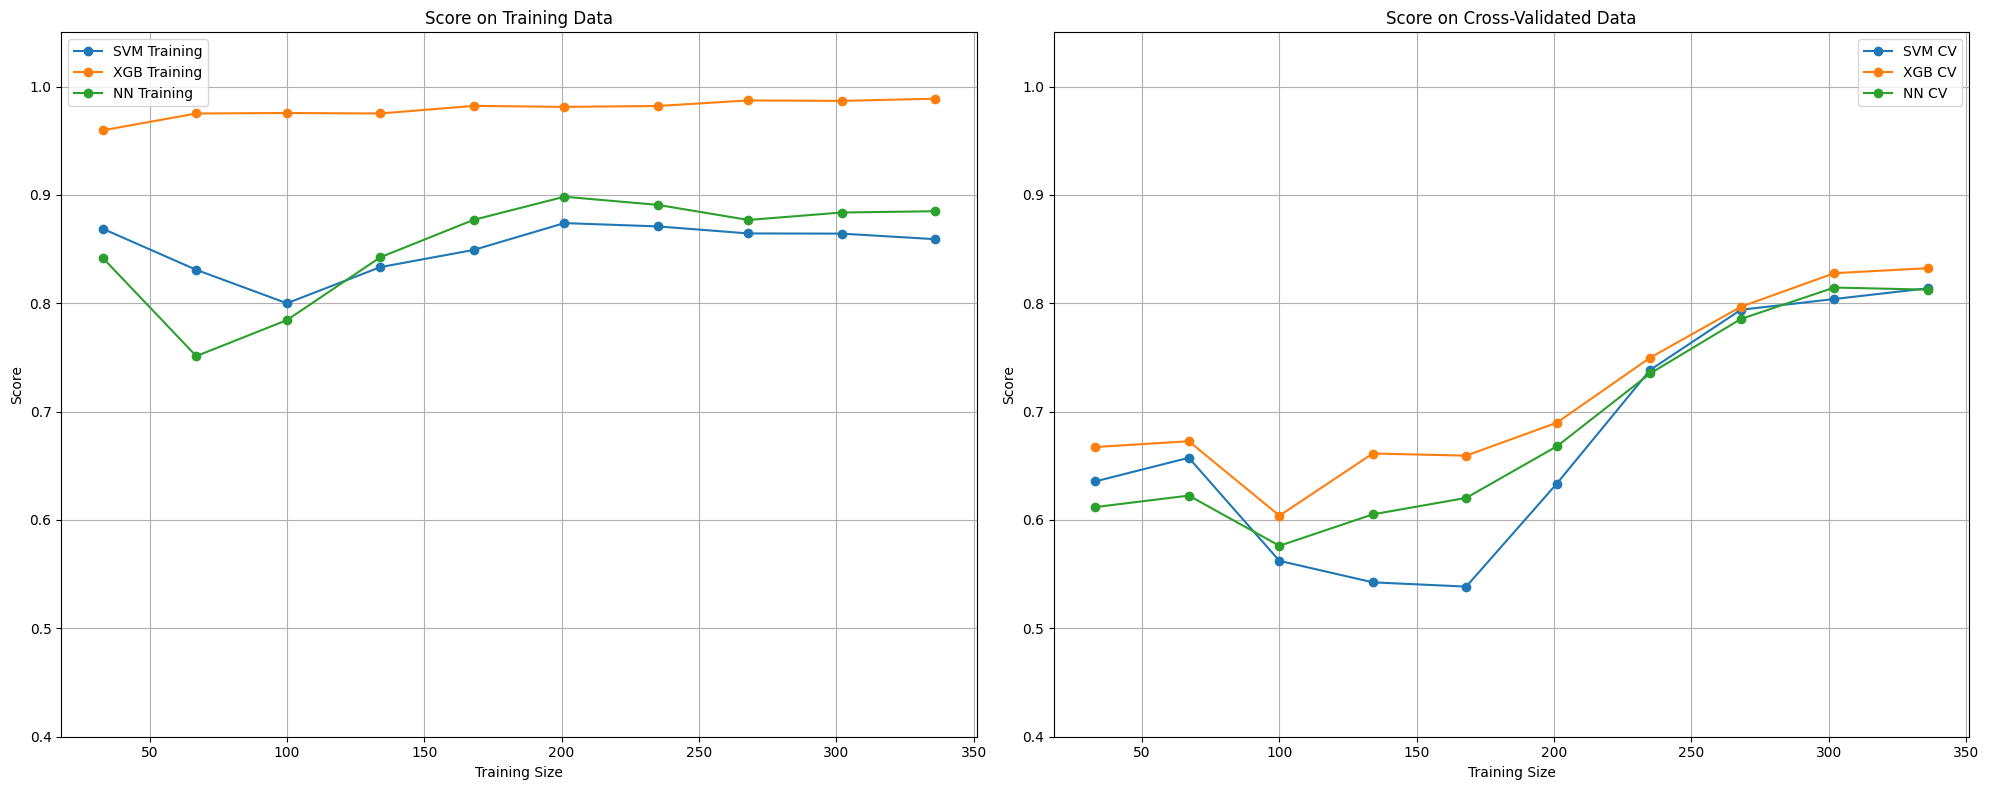

In [17]:
plt_lr.plot_learning_curve(models, y, train_sizes=np.linspace(0.1, 1, 10))

# Predictions
Loading the evaluation set that is to be used to make predictions on.

In [576]:
test = pd.read_csv(
    r"Data/project_test.csv",
    sep=",",
    decimal=".",    )

test.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.543,0.752,0,-9.986,1,0.1010,0.0224,0.000000,0.0683,0.904,168.122
1,0.483,0.753,1,-8.937,0,0.0832,0.4250,0.000142,0.2570,0.420,115.102
2,0.541,0.618,1,-9.652,0,0.1790,0.2770,0.000040,0.4130,0.680,145.464
3,0.539,0.884,9,-6.530,1,0.0403,0.3820,0.001660,0.7600,0.752,100.812
4,0.205,0.129,7,-18.197,1,0.0595,0.9680,0.946000,0.1010,0.296,136.871


In [577]:
missing_values = test.isnull().sum()
df_info = pd.DataFrame({
                        "Missing values": missing_values,
                        "Data type": test.dtypes
                        })
print(test.shape[0])
print(test.nunique())
df_info

75
danceability        72
energy              71
key                 12
loudness            74
mode                 2
speechiness         72
acousticness        74
instrumentalness    40
liveness            71
valence             72
tempo               75
dtype: int64


,Missing values,Data type
danceability,0,float64
energy,0,float64
key,0,int64
loudness,0,float64
mode,0,int64
speechiness,0,float64
acousticness,0,float64
instrumentalness,0,float64
liveness,0,float64
valence,0,float64


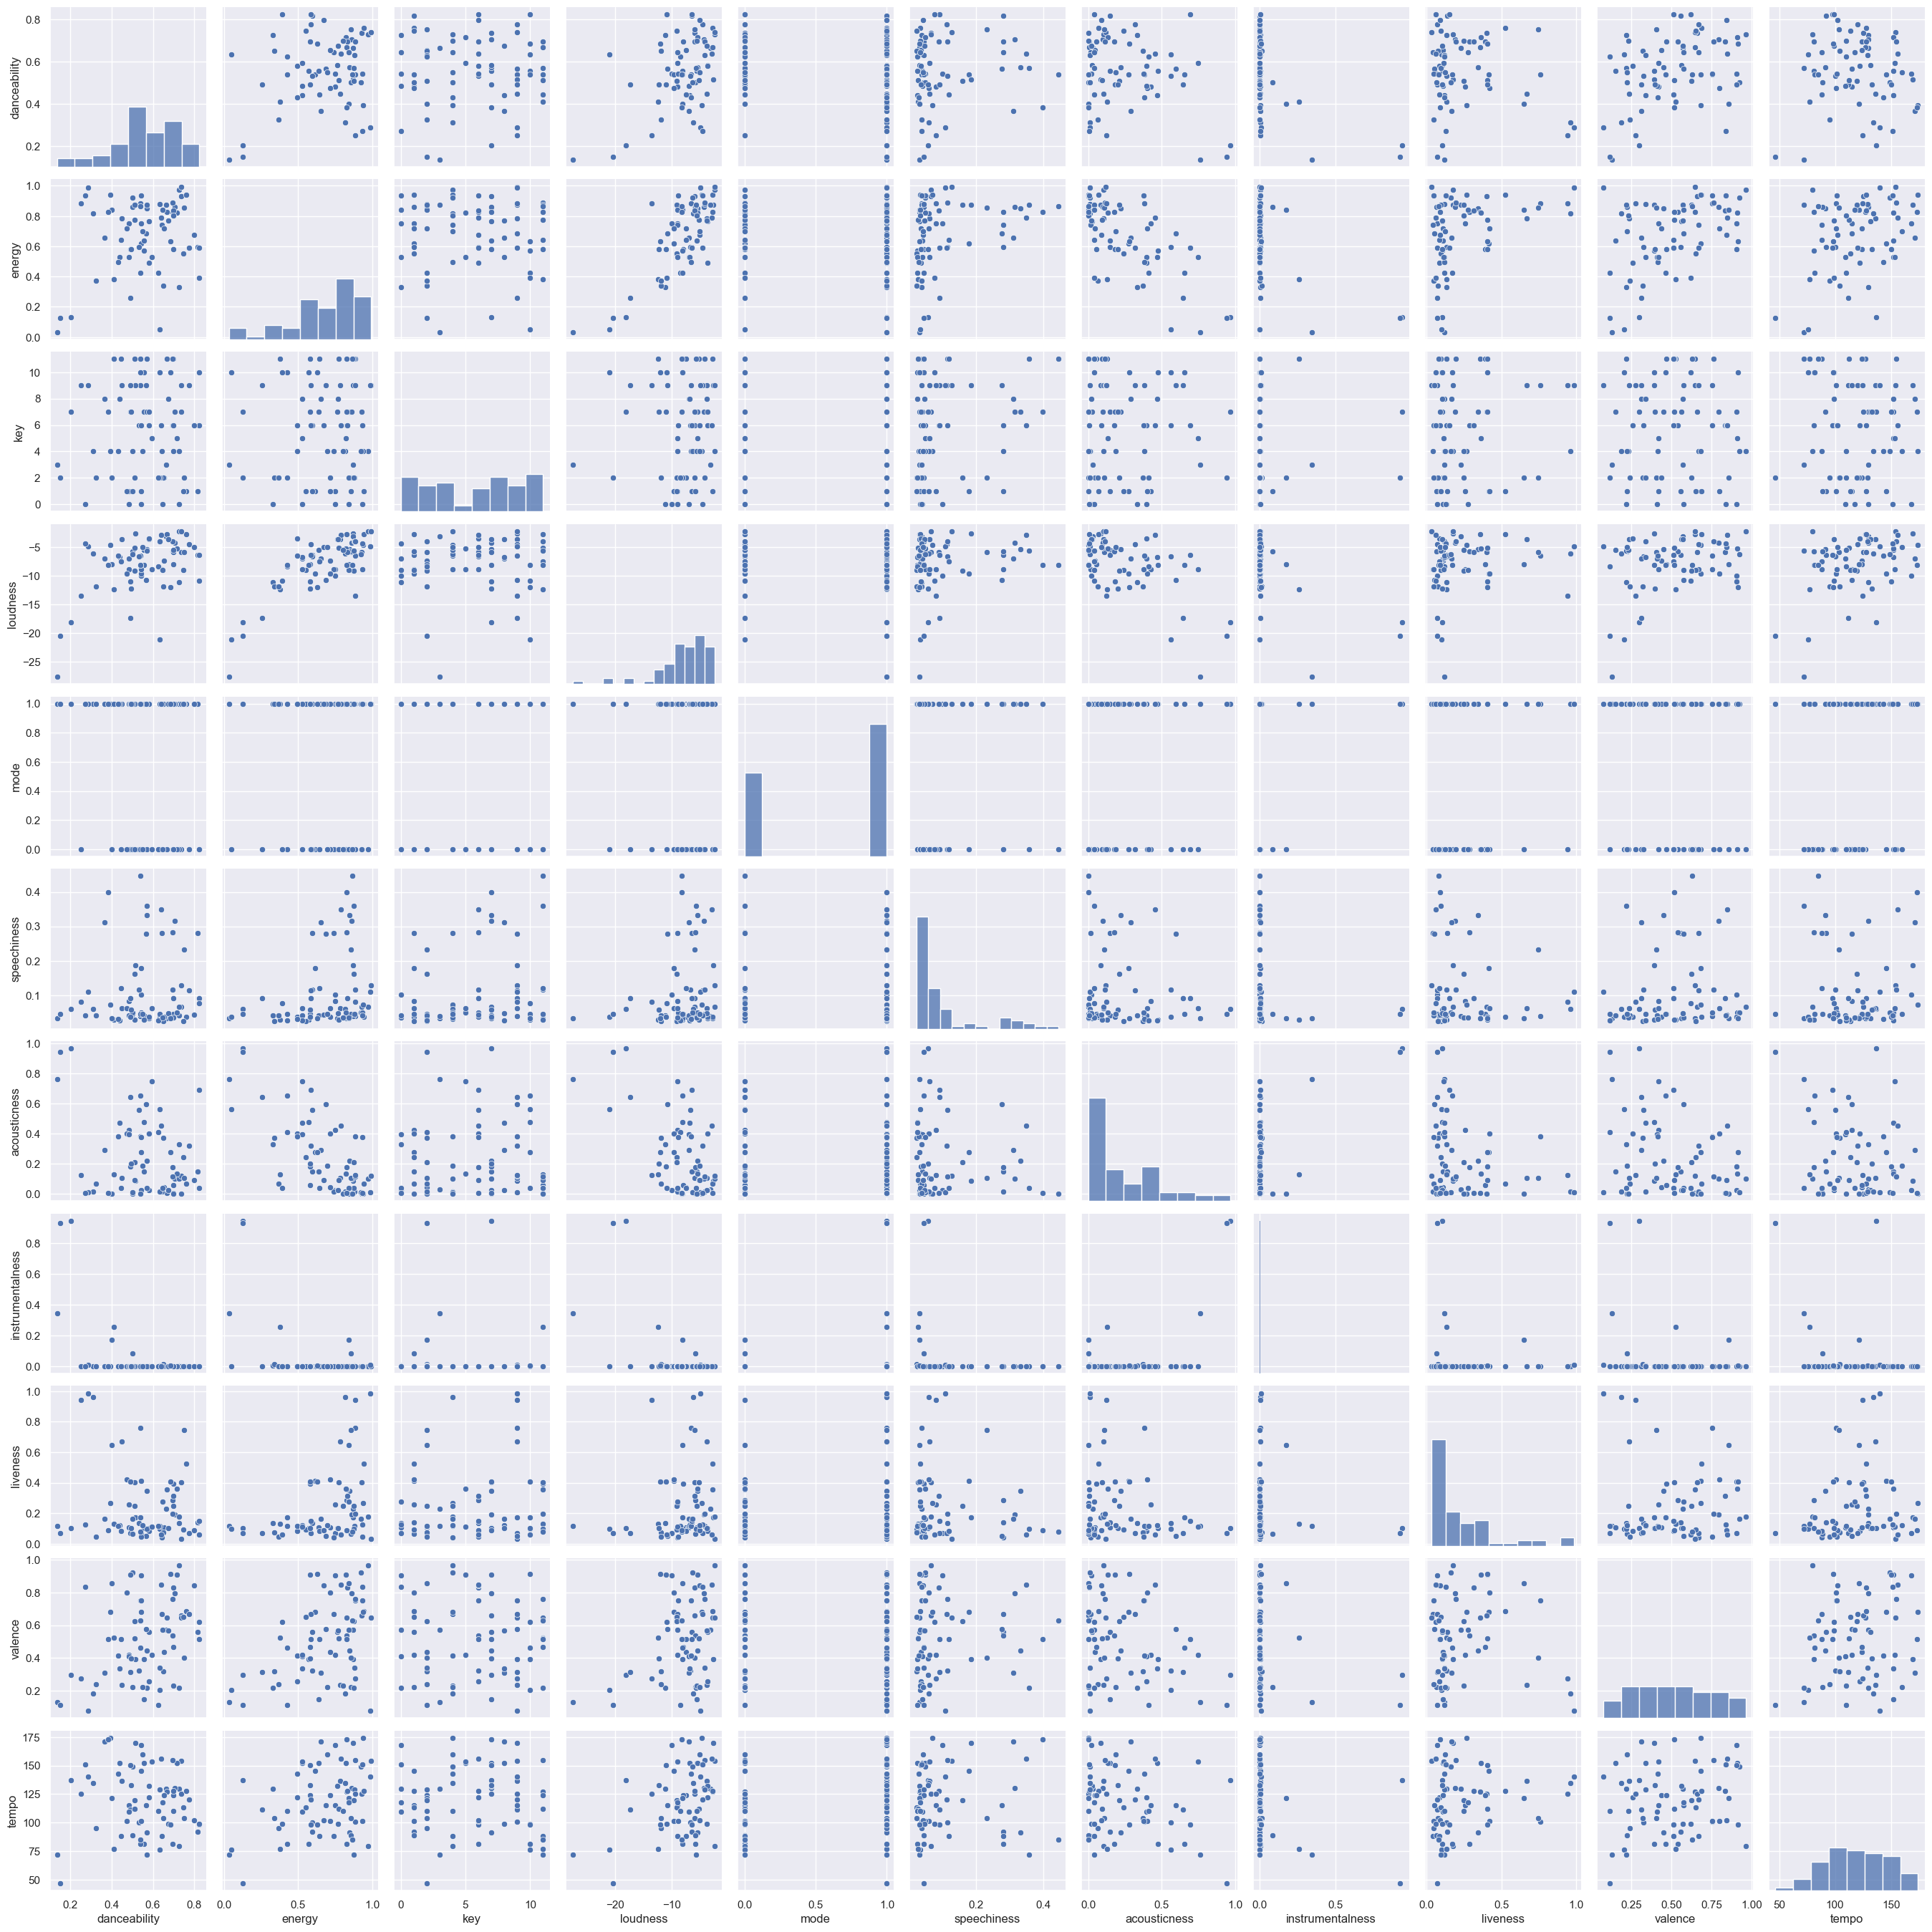

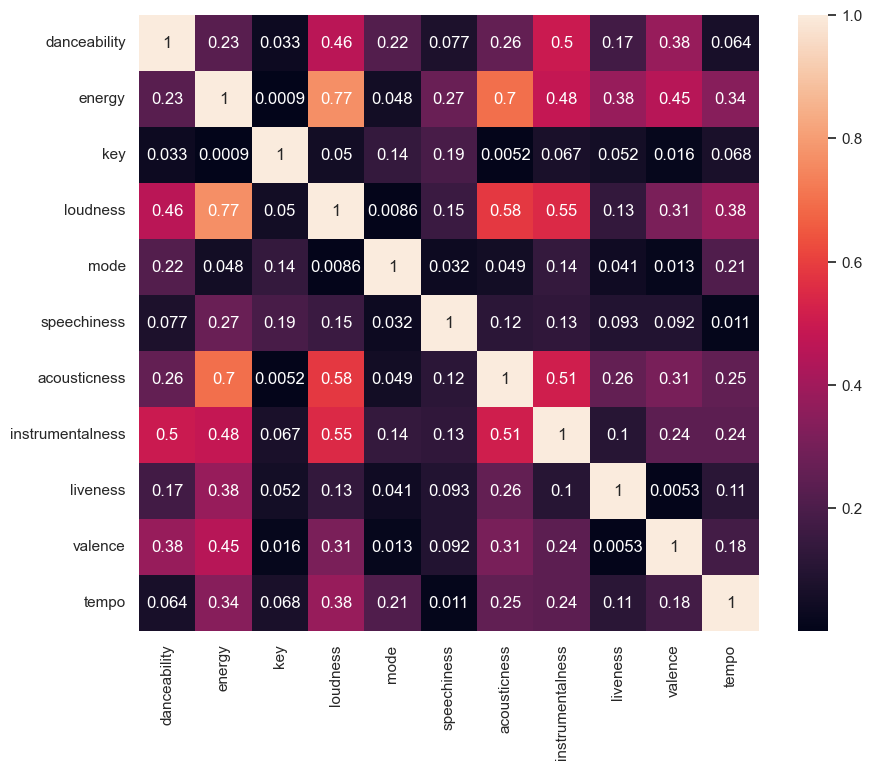

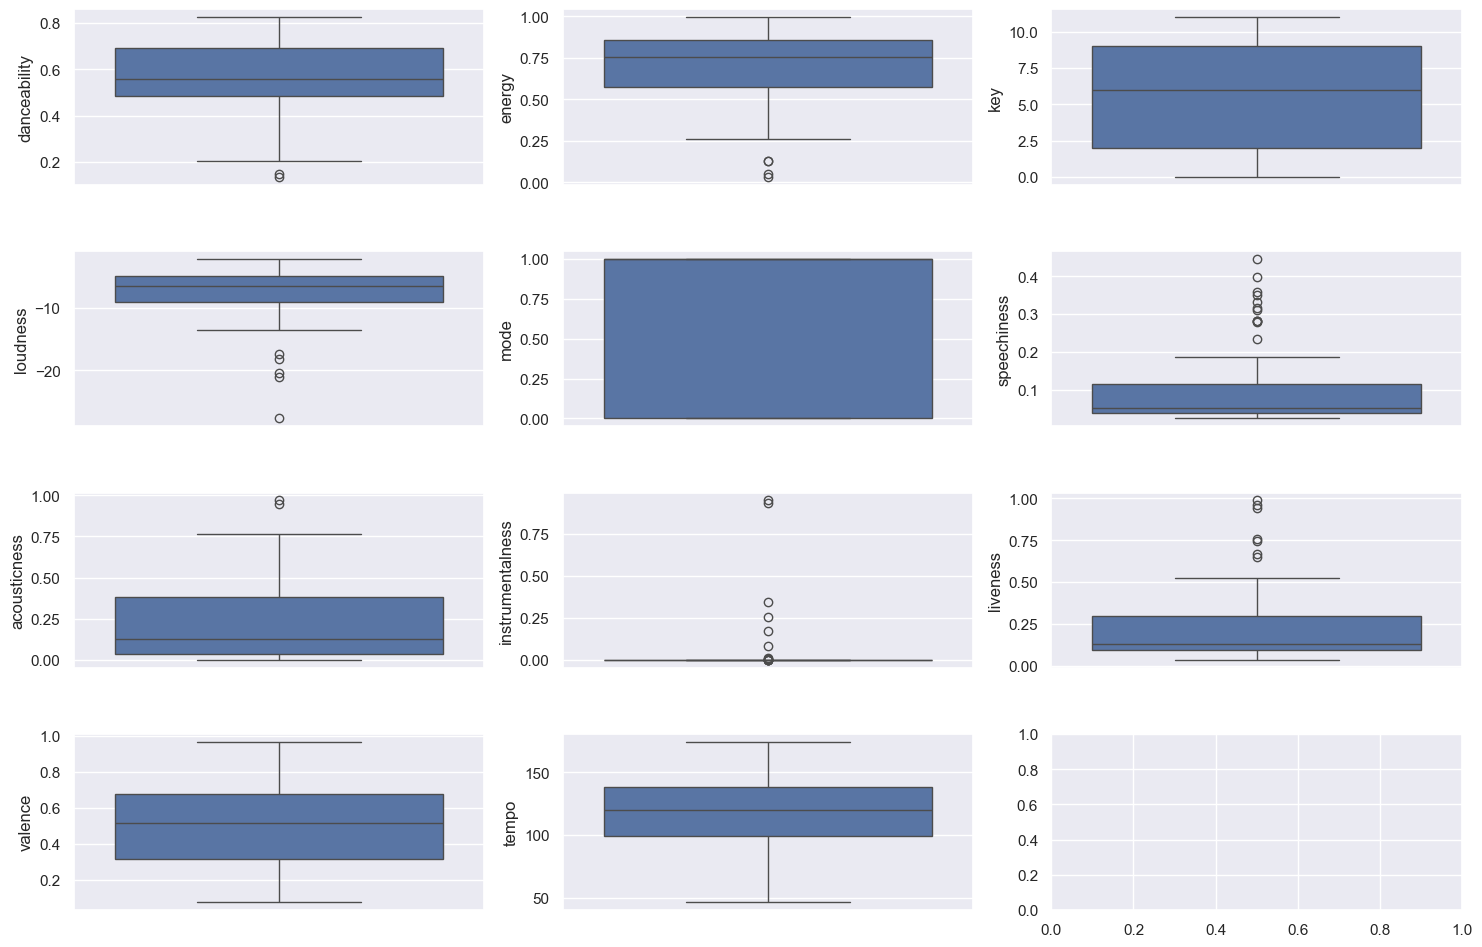

In [578]:
dc.plot_dist(test)

In [579]:
X_eval = test.iloc[:, :].values
X_eval.shape

(75, 11)

In [580]:
# y_lgb = lgb_model.predict(X_eval)
# y_xgb = xgb_model.predict(X_eval)
# y_svm = svm_model.predict(X_eval)
# y_knn = knn_model.predict(X_eval)
# y_nn = NN_model.predict(X_eval)
# X_eval_nn_sci = NN_model_sci.named_steps['feature_selection'].transform(X_eval)
# y_nn_sci = NN_model_sci.named_steps['model'].predict(X_eval_nn_sci)

In [582]:
# with open("predictions.csv", "w", newline='') as file:
#     writer = csv.writer(file)
#     for target in y_xgb:
#         writer.writerow([target])